# SVM classification of SWD and non-SWD EEG epochs

## Purpose
This notebook trains and evaluates a support vector machine (SVM) to distinguish spike-wave discharge (SWD) epochs from non-SWD epochs using the temporal and spectral features extracted in the preceding notebook.

## Workflow
1. Load the feature files produced for each EEG recording.
2. Standardise the features separately within each recording.
3. Combine the recording-level feature tables into one dataset.
4. Split the data into training and test sets while keeping all epochs from the same recording together.
5. Train an RBF-kernel SVM.
6. Evaluate performance using a classification report, confusion matrix, sensitivity, specificity and ROC AUC.
7. Inspect predicted probabilities and repeat the group-based split to assess robustness across different train-test partitions.

## Expected input
The `features` directory should contain one `.npz` file per recording. Each file is expected to contain:

- `X`: the feature matrix, with one row per epoch
- `y`: the binary class labels (`1 = SWD`, `0 = non-SWD`)
- `feature_names`: the names of the extracted features

The source filename is retained as `file_id` so that it can be used as the grouping variable during train-test splitting.


In [ ]:
# Import packages for file handling, numerical operations, tabular data and feature scaling.
import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Store the processed DataFrame from each recording before concatenation.
all_dfs = []

# Load every recording-level feature file from the features directory.
for file in os.listdir("features"):
    if file.endswith(".npz"):
        data = np.load(os.path.join("features", file))

        # Retrieve the feature matrix, class labels and corresponding feature names.
        X = data["X"]
        y = data["y"]
        feature_names = data["feature_names"]

        # Standardise the features separately within the current recording.
        # This places features on comparable numerical scales before the
        # recording-level datasets are combined.
        # scale THIS file only
        scaler = StandardScaler()
        X_scaled_file = scaler.fit_transform(X)

        # Convert the scaled matrix to a labelled table and retain both the
        # class label and source recording identifier.
        df = pd.DataFrame(X_scaled_file, columns=feature_names)
        df["label"] = y
        df["file_id"] = file

        all_dfs.append(df)

# Concatenate all recording-level tables into one dataset for modelling.
df_all_norm = pd.concat(all_dfs, ignore_index=True)

# Inspect the dimensions and first rows of the combined dataset.
print(df_all_norm.shape)
print(df_all_norm.head())


(358, 11)
       mean       std       max       min       rms  delta_1_4_power  \
0 -0.017466  0.731079  0.757760 -0.823863  0.729949         1.055151   
1  1.451360  1.241295  0.954793 -0.982352  1.241273         1.359452   
2  0.711590  0.942076  0.581467 -0.804052  0.941234         2.183183   
3 -0.937574  1.150341  1.229603 -0.422687  1.149515        -0.447537   
4 -1.547259  1.154589  1.239973 -0.913013  1.154665         1.479558   

   theta_4_8_power  alpha_8_13_power  beta_13_30_power  label  \
0         2.226732         -0.141205          1.111232      1   
1         2.284188          1.157363          1.638652      1   
2         0.538740          1.726929          0.486537      1   
3        -0.172186          2.124986          2.110383      1   
4         0.785081         -0.006949          1.167046      1   

                       file_id  
0  20150202AM0003_features.npz  
1  20150202AM0003_features.npz  
2  20150202AM0003_features.npz  
3  20150202AM0003_features.npz  
4

In [ ]:
# Separate the predictor features from the target labels and grouping variable.
# file_id is used only to control the split and is not supplied to the SVM.
X = df_all_norm.drop(columns=["label", "file_id"])
y = df_all_norm["label"]
groups = df_all_norm["file_id"]


In [ ]:
# Confirm the number of SWD and non-SWD epochs in the combined dataset.
print(df_all_norm["label"].value_counts())


label
1    179
0    179
Name: count, dtype: int64


# Group-aware train-test splitting

`GroupShuffleSplit` assigns complete recordings to either the training or test set. This prevents epochs originating from the same recording from appearing in both sets, thereby reducing the risk of data leakage caused by recording-specific similarities.

The initial split reserves approximately 30% of the recording groups for testing. `random_state=42` makes this partition reproducible.


In [ ]:
from sklearn.model_selection import GroupShuffleSplit

# Create one reproducible group-aware split, reserving approximately 30% of recording groups for the held-out test set.
gss = GroupShuffleSplit(test_size=0.3, n_splits=1, random_state=42)

# Use the generated indices to create the training and test datasets.
# All epochs sharing the same file_id are assigned to the same partition.
for train_idx, test_idx in gss.split(X, y, groups):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]


# Train the SVM classifier

An SVM with a radial basis function (RBF) kernel is trained using the selected hyperparameters. The nonlinear RBF kernel allows the model to learn a curved decision boundary between SWD and non-SWD epochs.

- `C=100` controls the penalty applied to classification errors.
- `gamma=0.1` controls the influence of individual training samples in the RBF kernel.
- `class_weight='balanced'` adjusts class weights according to their frequencies in the training data.
- `probability=True` enables predicted class probabilities for the ROC and probability-distribution analyses.


In [ ]:
from sklearn.svm import SVC

# Configure the nonlinear SVM using the final selected hyperparameters.
model = SVC(
    kernel='rbf',
    C=100,
    gamma=0.1,
    class_weight='balanced',
    probability=True
)

# Fit the classifier using only the training recordings.
model.fit(X_train, y_train)


SVC(C=100, class_weight='balanced', gamma=0.1, probability=True)

# Evaluate model performance

The trained model is applied to the held-out test recordings. Both discrete class predictions and estimated class probabilities are generated for subsequent evaluation.


In [ ]:
# Generate predicted class labels for the held-out test epochs.
y_pred = model.predict(X_test)

# Generate class-probability estimates. Column 1 represents P(SWD).
y_probs = model.predict_proba(X_test)


## Classification report and ROC AUC

The classification report summarises precision, recall and F1-score for each class. ROC AUC measures the model's ability to rank SWD epochs above non-SWD epochs across all possible classification thresholds; values closer to 1 indicate stronger discrimination.


In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

# Report precision, recall and F1-score for both classes.
print(classification_report(y_test, y_pred))

# Calculate ROC AUC using the probability assigned to the SWD class.
roc = roc_auc_score(y_test, y_probs[:, 1])
print("ROC AUC:", roc)


              precision    recall  f1-score   support

           0       1.00      0.99      0.99        70
           1       0.99      1.00      0.99        70

    accuracy                           0.99       140
   macro avg       0.99      0.99      0.99       140
weighted avg       0.99      0.99      0.99       140

ROC AUC: 0.9997959183673469


## Confusion matrix, sensitivity and specificity

The confusion matrix summarises the numbers of true negatives, false positives, false negatives and true positives.

- **Sensitivity** is the proportion of SWD epochs correctly detected.
- **Specificity** is the proportion of non-SWD epochs correctly identified.


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calculate the 2 × 2 confusion matrix from the true and predicted labels.
cm = confusion_matrix(y_test, y_pred)

# Create a labelled visual representation of the confusion matrix.
fig, ax = plt.subplots(figsize=(5,5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["non-SWD", "SWD"]
)

disp.plot(ax=ax)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


In [ ]:
# Unpack the confusion matrix into its four outcome categories.
tn, fp, fn, tp = cm.ravel()

# Sensitivity quantifies SWD detection, while specificity quantifies correct
# identification of non-SWD epochs.
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f"TN = {tn}")
print(f"FP = {fp}")
print(f"FN = {fn}")
print(f"TP = {tp}")
print(f"Sensitivity: {sensitivity:.3f}")
print(f"Specificity: {specificity:.3f}")


## ROC curve

The receiver operating characteristic curve plots the true-positive rate against the false-positive rate as the classification threshold is varied. The probabilities in column 1 correspond to the SWD class.


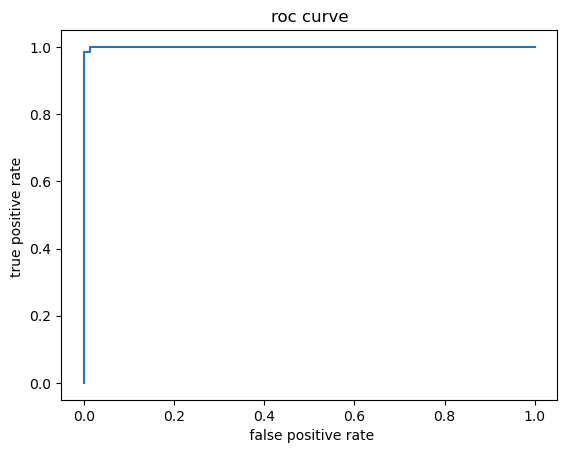

In [ ]:
import matplotlib.pyplot as plt 
from sklearn.metrics import roc_curve 

# Calculate the false-positive and true-positive rates across probability
# thresholds using the estimated probability of the SWD class.
fpr, tpr, thresholds = roc_curve(y_test, y_probs[:, 1])

# Plot the ROC curve for the initial held-out test set.
plt.plot(fpr, tpr)
plt.xlabel( " false positive rate")
plt.ylabel ("true positive rate ")
plt.title("roc curve")
plt.show()


# Additional checks of model performance

The following analyses inspect the confidence and stability of the model predictions. They are used to support interpretation of the main performance metrics.


## Inspection of predicted probabilities

The histogram displays the probability assigned to the SWD class for each test epoch. Predictions clustered near 0 and 1 indicate confident separation, whereas predictions close to 0.5 indicate greater uncertainty.


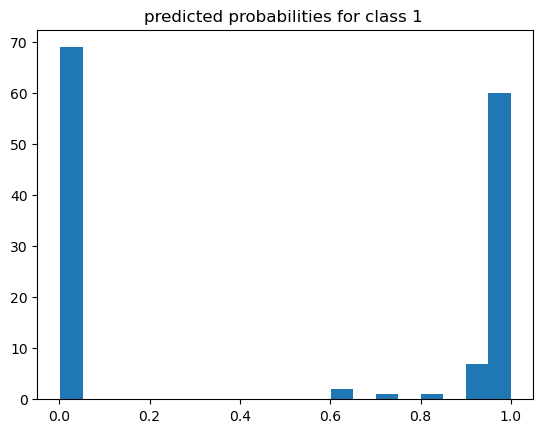

In [ ]:
import matplotlib.pyplot as plt

# Plot the distribution of probabilities assigned to the SWD class.
plt.hist(y_probs [:, 1], bins =20)
plt.title("predicted probabilities for class 1 ")
plt.show()


## Repeated group-based splitting

The group-aware split is repeated five times using different combinations of training and test recordings. Because grouping is based on `file_id`, complete recordings remain together within each partition rather than being divided at epoch level.

The ROC AUC from each split is printed to check whether performance is dependent on a single favourable train-test partition.


In [ ]:
# Generate five reproducible group-aware train-test partitions.
gss = GroupShuffleSplit(test_size=0.3, n_splits=5, random_state=42)
# n_splits=5 creates 5 different splits ( it'll randomnly assign different samples in the array to test and train)

#the for loop then loops through these 5 pairs 
for train_idx, test_idx in gss.split(X, y, groups):
    # Create the training and test datasets for the current group split.
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Refit the SVM on the recordings assigned to the current training set.
    model.fit(X_train, y_train)

    # Predict labels and SWD probabilities for the current test recordings.
    y_pred = model.predict(X_test)
    y_probs = model.predict_proba(X_test)

    from sklearn.metrics import roc_auc_score
    roc = roc_auc_score(y_test, y_probs[:, 1])

    


    # Print the ROC AUC obtained for the current partition.
    print("ROC AUC:", roc)


ROC AUC: 0.9997959183673469
ROC AUC: 1.0
ROC AUC: 0.9951439472771418
ROC AUC: 0.9982363315696648
ROC AUC: 0.9973230220107079


## Generalisability check across multiple group splits

The same five group-based partitions are evaluated in greater detail by printing the classification report and ROC AUC for each split. Similar performance across the splits would indicate that the result is reasonably robust to the particular recordings assigned to the test set.


In [ ]:
# Repeat detailed evaluation for each of the five group-aware partitions.
for i, (train_idx, test_idx) in enumerate(gss.split(X, y, groups)):
    
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Train the model on the current set of recording groups.
    model.fit(X_train, y_train)

    # Evaluate the fitted model on the held-out recording groups.
    y_pred = model.predict(X_test)
    y_probs = model.predict_proba(X_test)

    roc = roc_auc_score(y_test, y_probs[:, 1])

    # Print class-specific metrics and ROC AUC for this split.
    print(f"\n--- Split {i+1} ---")
    print(classification_report(y_test, y_pred))
    print("ROC AUC:", roc)



--- Split 1 ---
              precision    recall  f1-score   support

           0       1.00      0.99      0.99        70
           1       0.99      1.00      0.99        70

    accuracy                           0.99       140
   macro avg       0.99      0.99      0.99       140
weighted avg       0.99      0.99      0.99       140

ROC AUC: 0.9997959183673469

--- Split 2 ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        87
           1       1.00      0.98      0.99        87

    accuracy                           0.99       174
   macro avg       0.99      0.99      0.99       174
weighted avg       0.99      0.99      0.99       174

ROC AUC: 1.0

--- Split 3 ---
              precision    recall  f1-score   support

           0       0.99      0.98      0.98        93
           1       0.98      0.99      0.98        93

    accuracy                           0.98       186
   macro avg       0.98      0.98   